In [9]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


In [10]:
import pandas as pd

df = pd.read_csv("../data/17_열처리.csv")

import matplotlib.pyplot as plt

실습4. 제목·축·범례 갖춘 완성형 그래프
제목·축 이름·범례를 모두 갖춘 읽히는 그래프

목표
제목·축 이름·범례를 모두 갖춘 읽히는 그래프 완성

단계
· figsize로 가로로 긴 그래프 틀 만들기(plot보다 먼저)

· 두 설비를 색·마커를 달리해 겹쳐 그리기

· 제목·가로축·세로축 이름과 범례 위치를 지정

예상 결과
제목·축이름·범례를 갖춘 두 설비 비교 그래프

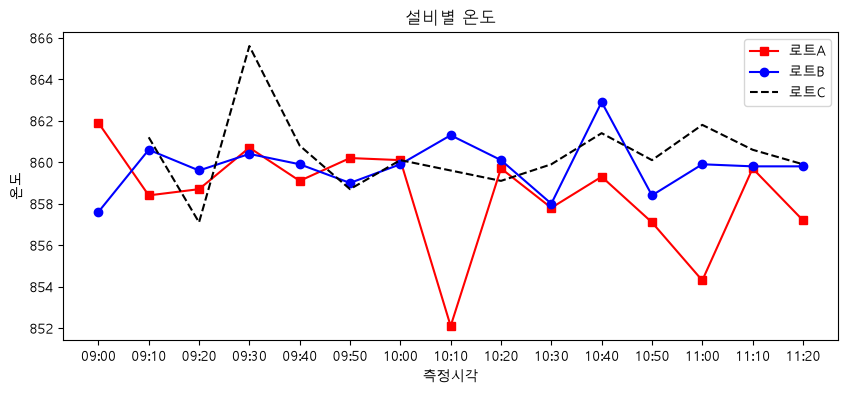

In [ ]:
df_a = df[df['배치'] == '로트A']
df_b = df[df['배치'] == '로트B']
df_c = df[df['배치'] == '로트C']

plt.figure(figsize=(10, 4)) # 전체 그래프의 크기
plt.title('설비별 온도')
plt.plot(df_a['측정시각'], df_a['온도'], label = '로트A', color = 'red', marker = 's')
plt.plot(df_b['측정시각'], df_b['온도'], label = '로트B', color = 'blue', marker = 'o')
plt.plot(df_c['측정시각'], df_c['온도'], label = '로트C', color = 'black', linestyle = '--')
plt.legend(loc = "upper right")
plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample.png')
plt.show()